# ETFs: Feasibility Analysis

Before building a trading strategy it is worth asking whether the data can support one at all.
This notebook does that and nothing else: it fits no model and makes no forecast.

The strategy being checked is described in `config/setup.yaml`. It trades exchange-traded funds,
ranks them once a month, and holds the ones that rank highest. That file says which funds it
trades, which of them count as liquid enough to hold, how often it changes positions, what it
assumes a trade costs, and how the history is divided between fitting a model and testing it.
This notebook checks each of those assumptions against the data and reports what it finds.

## Learning objectives

By the end of this notebook you will be able to:

- Decide which funds a strategy was allowed to hold on a given date using only information that
  existed before that date, and count how many that leaves on each date it changes positions
- Turn a commission quoted in cents per share into a cost that can be compared across funds
  trading at very different prices
- Read off one chart what fraction of price moves are larger than the cost of trading them
- Measure how much of one month's return carries into the next, and use that to judge whether a
  monthly rebalance is frequent enough to act on
- Check that a walk-forward split of the history fits the sample available and leaves the test
  period unread

## Book reference

Chapter 6, Sections 6.2-6.6. This notebook reads daily fund prices and `config/setup.yaml`, and
writes the eligibility table that the next two notebooks filter on.

## Prerequisites

None beyond what the sections below define. A reader who has not traded funds or split a sample
for walk-forward evaluation will find both explained where they are first used.

In [1]:
"""ETF Case Study - Feasibility Analysis."""

import re
import warnings

import matplotlib.pyplot as plt
import numpy as np
import polars as pl
import yaml
from IPython.display import display

from case_studies.utils.feasibility import exceedance_curve, fold_timeline, panel_acf
from data import load_etfs
from utils.cv_splits import generate_cv_splits
from utils.paths import get_case_study_dir
from utils.style import COLORS, FIGSIZE, add_message_title

warnings.filterwarnings("ignore")

In [2]:
CASE_STUDY_ID = "etfs"
START_DATE = "2006-01-01"
END_DATE = "2025-12-31"
ADV_THRESHOLD = 10e6
MIN_SESSIONS_PER_YEAR = 200

## Configuration

Everything the strategy assumes is declared in `config/setup.yaml`, and this notebook reads those
values rather than repeating them, so the two can never disagree. Four groups of settings matter
here, and each one decides something the sections below test.

**How the history is divided.** The sample runs from 2006 to the end of 2025. The last two years
are the *holdout*: a stretch of history that is not looked at while the strategy is being
designed, so that when it is finally evaluated there, the result is not a rehearsal of choices
already tuned on the same data. Everything computed in this notebook uses the earlier part,
called the development period. `holdout_start` is where the line falls.

**What the strategy trades.** `setup.yaml` names 100 funds. Not all of them are tradable at all
times: a fund is admitted to a year only if it traded enough in the year before, which Section
B.2 explains and applies. The strategy holds the leaders only, up to 20 of them, so at least 20
funds have to be admitted on any date it rebalances. That floor comes from the grid of portfolio
sizes the strategy will later search over, not from a separate assumption.

**What a trade is assumed to cost.** Two charges, both quoted in dollars per share: a broker
commission, and half the gap between the price a buyer will pay and the price a seller will
accept. Section B.3 turns them into a cost that is comparable across funds.

**What is being predicted.** The strategy forecasts returns 21 sessions ahead, roughly one month,
and a second variant looks 5 sessions ahead. The 21-session horizon is the primary one, and it
sets both the rebalancing frequency and the gap that has to separate training from validation
data.

One value the strategy depends on is not machine-readable in `setup.yaml`: the dollar-volume
floor a fund has to clear appears only inside `universe.eligibility_note`, as prose. It is
therefore set in the parameters cell above, and Section B.2 says what it does.

In [3]:
CASE_DIR = get_case_study_dir(CASE_STUDY_ID)
SETUP = yaml.safe_load((CASE_DIR / "config" / "setup.yaml").read_text())

HOLDOUT_START = str(SETUP["evaluation"]["holdout_start"])
HOLDOUT_END = str(SETUP["evaluation"]["holdout_end"])
PRIMARY_LABEL = SETUP["labels"]["primary"]
LABEL_BUFFER = SETUP["labels"]["buffer"]
DECLARED_ASSETS = set(SETUP["universe"]["assets"])
BREADTH_FLOOR = max(SETUP["backtest"]["sweep"]["top_k_grid"][PRIMARY_LABEL])
PER_SHARE = SETUP["costs"]["per_share"]
HALF_SPREADS = SETUP["costs"]["asset_spreads"]
DEFAULT_HALF_SPREAD = SETUP["costs"]["default_half_spread_usd"]
LABELS = [PRIMARY_LABEL, *SETUP["labels"]["variants"]]
HORIZONS = sorted(int(re.search(r"(\d+)d$", n).group(1)) for n in LABELS)
PRIMARY_HORIZON = int(re.search(r"(\d+)d$", PRIMARY_LABEL).group(1))

print(f"Sample: {START_DATE} to {END_DATE}")
print(f"  Development period, used everywhere below:  {START_DATE} to {HOLDOUT_START}")
print(f"  Holdout, not read by this notebook:         {HOLDOUT_START} to {HOLDOUT_END}")
print(f"Universe: {len(DECLARED_ASSETS)} funds declared")
print(
    f"  Up to {BREADTH_FLOOR} held at once, so at least {BREADTH_FLOOR} must be admitted on a "
    f"rebalancing date to fill the book"
)
print(
    f"  Admitted to a year after averaging ${ADV_THRESHOLD / 1e6:.0f}M of daily turnover in the "
    f"year before"
)
print(
    f"Assumed cost: ${PER_SHARE} per share in commission, plus a half-spread of "
    f"${min(HALF_SPREADS.values())} to ${DEFAULT_HALF_SPREAD} per share by liquidity tier"
)
print(
    f"Forecast horizons: {' and '.join(f'{h} sessions' for h in HORIZONS)} ahead; "
    f"{PRIMARY_HORIZON} sessions is the primary horizon and sets the rebalancing frequency"
)

Sample: 2006-01-01 to 2025-12-31
  Development period, used everywhere below:  2006-01-01 to 2024-01-01
  Holdout, not read by this notebook:         2024-01-01 to 2025-12-31
Universe: 100 funds declared
  Up to 20 held at once, so at least 20 must be admitted on a rebalancing date to fill the book
  Admitted to a year after averaging $10M of daily turnover in the year before
Assumed cost: $0.0035 per share in commission, plus a half-spread of $0.005 to $0.02 per share by liquidity tier
Forecast horizons: 5 sessions and 21 sessions ahead; 21 sessions is the primary horizon and sets the rebalancing frequency


## A. Orientation

### What an exchange-traded fund is

An exchange-traded fund holds a portfolio - the shares in an index, a basket of bonds, a stock of
gold in a vault - and issues shares in itself that trade on an exchange like any other stock. A
buyer of one share owns a slice of whatever the fund holds, and can buy or sell it during the
trading day at whatever price the exchange is quoting, rather than subscribing or redeeming with
the fund manager. That is what makes a portfolio like this one practical: exposure to Japanese
equities, to investment-grade credit and to gold are the same kind of instrument, bought the same
way, in the same account, with the same order type.

The hundred funds this strategy trades cover most of what an investor can hold that way: broad
equity indices, the sectors within them, individual countries, government and corporate bonds,
currencies, commodities, and rules-based selections such as high-dividend or low-volatility
baskets.

### Why ranking funds is a strategy at all

The strategy does not take a view on any one market. Once a month it sorts the funds it is
allowed to hold by some measure of their recent behaviour, buys the ones at the top, and sells
whatever has dropped out. What it is betting on is that the ordering carries: that a fund near the
top this month is more likely than not to be above average next month. Whether that is true is a
question for Chapter 7 onwards. What this notebook asks is whether the data could support the
attempt.

A strategy of that shape needs breadth more than it needs depth. Choosing 20 funds out of 5 is not
a choice, so it matters more that many funds are quoting at once than that any one of them is
quoting well.

### The three questions this notebook asks

1. **Does the universe exist when the strategy trades?** Positions change once a month, so enough
   funds have to be tradable on each of those dates to fill the book.
2. **Is a typical price move worth more than it costs to capture?** Every round trip pays a
   commission and crosses the gap between the buying and the selling price, twice, and those
   charges are a different fraction of the price for a $20 fund than for a $500 one.
3. **Is there enough history to evaluate this honestly?** Enough to split into training and
   validation periods several times over, with the holdout left untouched.

## B. Universe and cost feasibility

### B.1 Load the data and look at the universe

The loader returns one row per fund and session. Its `close` is *adjusted*: when a fund splits its
shares or pays a distribution, the whole earlier history is rescaled so that the change does not
appear as a price move. Differences of an adjusted series are therefore returns rather than
corporate-action artefacts, which is why it is the series used for measuring moves. It has a
consequence worth knowing now, and Section B.2 runs into it: an adjusted price from years ago is
lower than the price the fund actually traded at that day.

Two properties are checked before anything is computed: nothing outside the declared list of
funds, and no close at or below zero, since every ratio below divides by one.

In [4]:
prices = (
    load_etfs(start_date=START_DATE, end_date=END_DATE)
    .select(["symbol", "timestamp", "close", "volume"])
    .sort(["symbol", "timestamp"])
)
research = prices.filter(pl.col("timestamp") < pl.lit(HOLDOUT_START).str.to_date())

undeclared = sorted(set(prices["symbol"].unique().to_list()) - DECLARED_ASSETS)
assert not undeclared, f"loaded but absent from setup.yaml::universe.assets: {undeclared}"
assert prices["close"].min() > 0, "a non-positive close is not a denominator"
print(
    f"{research['symbol'].n_unique()} funds, {len(research):,} daily closes, "
    f"{research['timestamp'].min()} to {research['timestamp'].max()}"
)

100 funds, 420,462 daily closes, 2006-01-03 to 2023-12-29


A hundred tickers is a list, not a description. The way the cost model already groups them is by
how much they trade, because that is what decides how wide the gap between the buying and the
selling price is likely to be. `setup.yaml::costs.asset_spreads` names two tiers and leaves the
rest to a default:

- **Half a cent** for the seven funds tracking the largest indices: the S&P 500, the Nasdaq 100,
  the Dow, the Russell 2000, the total US market, developed markets outside the US, and emerging
  markets.
- **One cent** for the eleven funds holding the sectors of the S&P 500, one each.
- **Two cents** for the remaining funds: countries, bonds, currencies, commodities, industries and
  rules-based selections.

That assignment comes from industry knowledge rather than from the data, because daily bars carry
no bid and no ask. The table below is the check on it. *Turnover* is the number of shares that
changed hands multiplied by the price, so it measures money traded rather than shares traded, and
it is the quantity Section B.2's eligibility rule reads. If the tiers are sensible, turnover should
fall as the assumed spread widens, and it does, by roughly a factor of five at each step.

In [5]:
half_spread = pl.col("symbol").replace_strict(
    HALF_SPREADS, default=DEFAULT_HALF_SPREAD, return_dtype=pl.Float64
)
arrivals = research.group_by("symbol").agg(pl.col("timestamp").min().alias("arrived"))
tiers = (
    research.with_columns(half_spread_usd=half_spread, turnover=pl.col("close") * pl.col("volume"))
    .join(arrivals, "symbol")
    .group_by("half_spread_usd")
    .agg(
        pl.col("symbol").n_unique().alias("funds"),
        pl.col("close").median().round(2).alias("median_close_usd"),
        (pl.col("turnover").median() / 1e6).round().cast(pl.Int64).alias("median_turnover_musd"),
        pl.col("arrived").max().alias("last_arrival"),
    )
    .sort("half_spread_usd")
)
with pl.Config(tbl_rows=tiers.height, tbl_cols=tiers.width):
    display(tiers)

half_spread_usd,funds,median_close_usd,median_turnover_musd,last_arrival
f64,u32,f64,i64,date
0.005,7,77.38,1766,2006-01-03
0.01,11,24.32,393,2018-06-19
0.02,82,41.95,63,2013-07-18


### B.2 How many funds the strategy is allowed to hold when it rebalances

Not every fund can be held on every date. A fund that barely traded in 2009 could not have been
bought in size in 2009, whatever it does today, so the strategy admits a fund to a year only if it
averaged more than the declared floor in daily turnover over the *previous* year. Deciding
membership from the year before is what makes the rule usable in real time: on the first trading
day of any year, everything it reads has already happened.

The alternative is the mistake this guards against. Selecting funds on turnover measured over the
whole sample would admit exactly the funds that turned out to stay liquid, and the strategy would
be tested on a universe assembled with knowledge it could not have had. A rule read on prior
information only is called *point-in-time*, and it is the difference between a backtest and a
rehearsal.

Two details of the rule are worth stating. A fund quoting for only part of a year has no full year
of turnover to be admitted on, so a minimum number of trading days is required before the average
means anything. And the turnover is computed from the adjusted close described above, which
understates what a fund actually traded in its early years - so the rule is slightly stricter in
the distant past than a rule reading traded prices would be. The daily bars carry no unadjusted
price, so that is a property of the data rather than a choice.

In [6]:
eligibility = (
    prices.with_columns(
        turnover=pl.col("close") * pl.col("volume"), year=pl.col("timestamp").dt.year()
    )
    .group_by(["symbol", "year"])
    .agg(pl.col("turnover").mean().alias("avg_turnover"), pl.len().alias("n_days"))
    .filter((pl.col("n_days") >= MIN_SESSIONS_PER_YEAR) & (pl.col("avg_turnover") >= ADV_THRESHOLD))
    .select("symbol", (pl.col("year") + 1).alias("eligible_year"))
    .unique()
    .sort(["symbol", "eligible_year"])
)

A single count over the whole sample would hide the question a strategy of this shape has to
answer, which is whether enough funds are admitted *at the moment it has to choose between them*.
The strategy rebalances at the last session of each month, so that is where the count is taken,
and it is compared against the 20 positions the largest book has to fill.

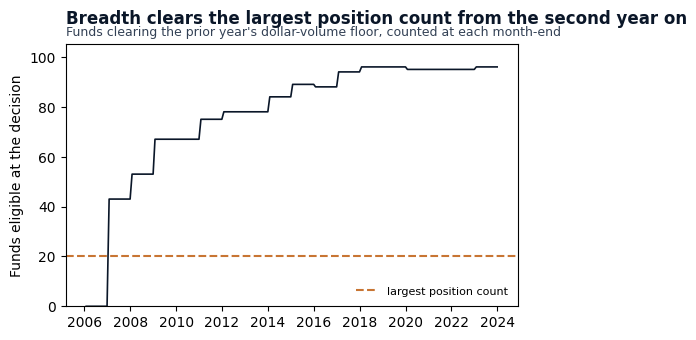

In [7]:
month_end = research.filter(
    pl.col("timestamp") == pl.col("timestamp").max().over(pl.col("timestamp").dt.truncate("1mo"))
)
eligible = eligibility.rename({"eligible_year": "year"}).with_columns(eligible=pl.lit(True))
breadth = (
    month_end.with_columns(year=pl.col("timestamp").dt.year())
    # a left join keeps the dates on which nothing is eligible, which an inner join drops
    .join(eligible, ["symbol", "year"], how="left")
    .group_by("timestamp")
    .agg(pl.col("eligible").fill_null(False).sum().alias("n_eligible"))
    .sort("timestamp")
)

fig, ax = plt.subplots(figsize=FIGSIZE["single"])
ax.plot(breadth["timestamp"], breadth["n_eligible"], color=COLORS["blue"], linewidth=1.2)
ax.axhline(BREADTH_FLOOR, color=COLORS["copper"], ls="--", lw=1.5, label="largest position count")
ax.set_ylim(0, len(DECLARED_ASSETS) + 5)
ax.set_ylabel("Funds eligible at the decision")
ax.legend(frameon=False, fontsize=8, loc="lower right")
add_message_title(
    ax,
    "Breadth clears the largest position count from the second year on",
    subtitle="Funds clearing the prior year's dollar-volume floor, counted at each month-end",
)
plt.show()

### B.3 What a round trip costs, and what a move is worth

Buying and later selling the same fund pays two charges, and pays each of them twice.

The first is the broker's **commission**, quoted in cents per share. The second is the **spread**:
at any moment there is a price at which someone will sell and a slightly higher price at which
someone will buy, and a trade that has to happen now crosses that gap. By convention the cost is
charged as half the gap on each side of the round trip, which is why `setup.yaml` states it as a
*half-spread*. Both charges are dollars per share, and neither has anything to do with how
expensive the share is - so the same two cents is a heavier charge on a fund trading at $20 than
on one trading at $500.

That is why the cost has to be converted before it can be compared to a return. Expressed as a
fraction of the price, it becomes a number that means the same thing for every fund. The unit
below is the **basis point**, one hundredth of one percent, which is the conventional unit for
quantities this small.

One caveat on the spread. Daily bars record what traded, not what was quoted, so there is no bid
and no ask in this data and the half-spread cannot be measured from it. It is assigned by tier, as
B.1 described, and `16_costs` re-runs the strategy under harsher assumptions to see how much the
answer depends on it.

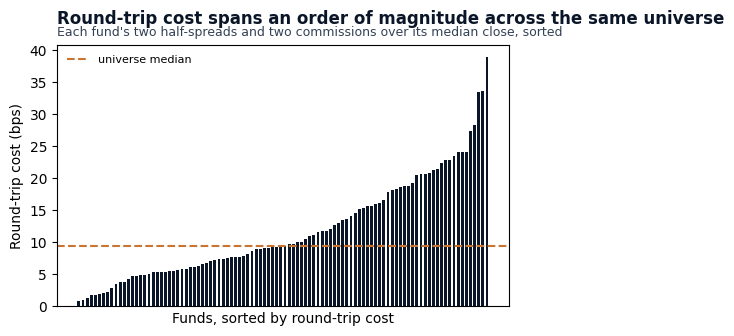

In [8]:
cost = (
    research.group_by("symbol")
    .agg(pl.col("close").median().alias("price"))
    .with_columns((2 * (half_spread + PER_SHARE) / pl.col("price") * 1e4).alias("cost_bps"))
    .sort("cost_bps")
)
COST_BPS = float(cost["cost_bps"].median())

fig, ax = plt.subplots(figsize=FIGSIZE["single"])
ax.bar(cost["symbol"], cost["cost_bps"], color=COLORS["blue"], width=0.7)
ax.axhline(COST_BPS, color=COLORS["copper"], ls="--", lw=1.5, label="universe median")
ax.set_ylabel("Round-trip cost (bps)")
ax.set_xlabel("Funds, sorted by round-trip cost")
ax.set_xticks([])  # a hundred tickers are unreadable, and the spread of the curve is the point
ax.legend(frameon=False, fontsize=8)
add_message_title(
    ax,
    "Round-trip cost spans an order of magnitude across the same universe",
    subtitle="Each fund's two half-spreads and two commissions over its median close, sorted",
)
plt.show()

Because those costs differ by an order of magnitude, a single cost line drawn across raw returns
would answer the question for no fund in particular: a move that clears the charge on a
large-index fund need not clear it on a thinly traded one. Each move is therefore divided by what
its own fund would have charged at the price the position opened at. On that scale the break-even
point is 1 for every fund, whatever its own cost happens to be.

The chart below is an **exceedance curve**, and it reads from the right: for each multiple on the
horizontal axis, the curve gives the fraction of moves at least that large. Where it crosses the
line at 1 is the fraction of moves bigger than the cost of trading them.

It is drawn over the fund-years the eligibility rule admits, not over every row of the panel. A
move in a fund the strategy was not allowed to hold that year is not an opportunity it missed, and
counting it would overstate how often a move clears its cost.

One thing this chart is not. It is the distribution of how far prices move, measured over every
admitted fund and every session in the development period, ignoring direction. It is not the
return a strategy would earn: nothing here is signed, nothing waits a day to enter, and nothing is
restricted to the rebalancing dates. Whether the strategy can pick which moves to be on the right
side of is the question Chapter 7 onwards asks. This is only whether the moves are large enough to
be worth trying.

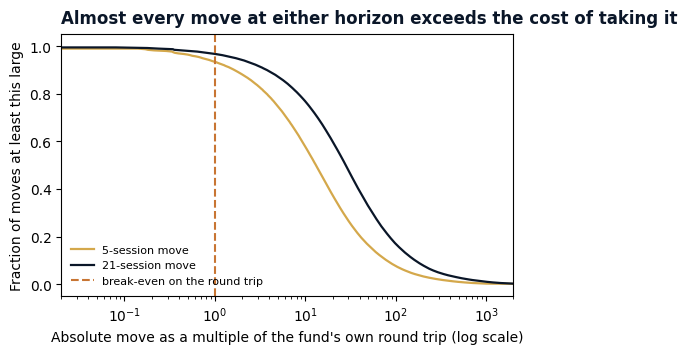

In [9]:
tradable = research.with_columns(year=pl.col("timestamp").dt.year()).join(
    eligibility.rename({"eligible_year": "year"}), ["symbol", "year"], how="semi"
)
returns = tradable.with_columns(
    cost_bps=2 * (half_spread + PER_SHARE) / pl.col("close") * 1e4
).with_columns(
    (pl.col("close").pct_change(h).abs() * 1e4 / pl.col("cost_bps").shift(h))
    .over("symbol")
    .alias(f"h{h}")
    for h in HORIZONS
)

fig, ax = plt.subplots(figsize=FIGSIZE["single"])
for h, color in zip(HORIZONS, (COLORS["amber"], COLORS["blue"]), strict=True):
    multiple, fraction = exceedance_curve(returns[f"h{h}"].drop_nulls().to_numpy())
    ax.plot(multiple, fraction, color=color, lw=1.6, label=f"{h}-session move")
ax.axvline(1, color=COLORS["copper"], ls="--", lw=1.5, label="break-even on the round trip")
ax.set_xscale("log")
ax.set_xlim(0.02, 2_000)
ax.set_xlabel("Absolute move as a multiple of the fund's own round trip (log scale)")
ax.set_ylabel("Fraction of moves at least this large")
ax.legend(frameon=False, fontsize=8, loc="lower left")
add_message_title(ax, "Almost every move at either horizon exceeds the cost of taking it")
plt.show()

### B.4 Serial correlation of the carrier

The carrier is what the ranking is built from: the return between consecutive decision dates. Its
serial correlation inside each fund says how much of one month's return the next repeats, a
property of that series and not of the cross-sectional ranking, which `05_evaluation` measures.
Stacking a hundred funds and correlating the result would measure their joins instead.

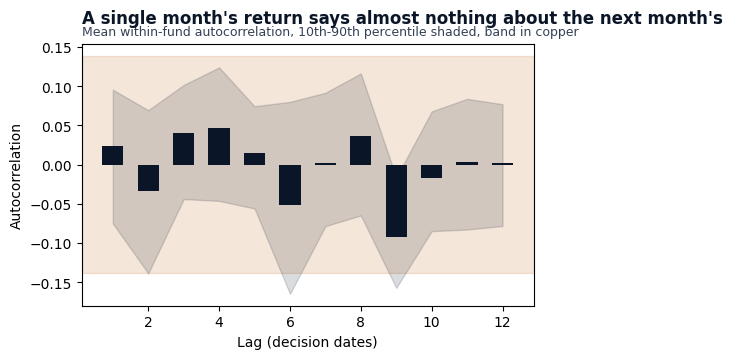

In [10]:
monthly = month_end.with_columns(monthly_return=pl.col("close").pct_change().over("symbol"))
# lag zero is a series against itself, and its bar would flatten every other one
acf = panel_acf(monthly, entity_col="symbol", value_col="monthly_return", max_lags=12).filter(
    pl.col("lag") > 0
)

fig, ax = plt.subplots(figsize=FIGSIZE["single"])
ax.axhspan(-acf["band"][0], acf["band"][0], color=COLORS["copper"], alpha=0.18, zorder=0)
ax.fill_between(acf["lag"], acf["acf_p10"], acf["acf_p90"], color=COLORS["blue"], alpha=0.15)
ax.bar(acf["lag"], acf["acf"], color=COLORS["blue"], width=0.6)
ax.set_xlabel("Lag (decision dates)")
ax.set_ylabel("Autocorrelation")
add_message_title(
    ax,
    "A single month's return says almost nothing about the next month's",
    subtitle="Mean within-fund autocorrelation, 10th-90th percentile shaded, band in copper",
)
plt.show()

### B.5 Move scale against cost

The ratio divides the median absolute move at the primary horizon by the median round trip; the
clearance share counts moves above what their own fund charged. Both are unsigned magnitudes, so
neither says a strategy earns anything - only that cost is not what would stop one.

In [11]:
moves = returns.select(
    move_bps=1e4 * pl.col("close").pct_change(PRIMARY_HORIZON).abs().over("symbol"),
    clears=pl.col(f"h{PRIMARY_HORIZON}") > 1,
)
print(
    f"Round-trip cost {cost['cost_bps'].min():.2f} to {cost['cost_bps'].max():.2f} bps, median "
    f"{COST_BPS:.2f} bps | median {PRIMARY_HORIZON}-session move "
    f"{moves['move_bps'].median():.1f} bps, ratio {moves['move_bps'].median() / COST_BPS:.0f}x, "
    f"over its own fund's cost {moves['clears'].mean():.3f}"
)

Round-trip cost 0.90 to 38.91 bps, median 9.45 bps | median 21-session move 286.2 bps, ratio 30x, over its own fund's cost 0.968


The round trip costs 0.90 to 38.91 bps at each fund's median close, a universe median of 9.45. The
median absolute 21-session move is 286.2 bps, 30x that, and 0.968 of moves clear their entry cost.

## C. Design decisions

### C.1 Cadence. `setup.yaml::decision.cadence` ranks funds at the month-end close and executes at
the next open. B.3 supports rebalancing that often, since moves at both declared horizons clear
the round trip their own fund charges. A month also buys a purge gap the width of the primary
label, and the weekly horizon stays in `labels.variants` so the shorter holding period is measured.

### C.2 Kill conditions. Three thresholds send the strategy back to the drawing board, each tested
where its evidence exists rather than here: a cross-sectional information coefficient
indistinguishable from zero at every lookback, measured in Chapter 7; a move-to-cost ratio under
one once realistic costs are charged, measured in Chapter 18; and an equal-weight book earning a
higher Sharpe ratio at a smaller drawdown across folds, measured in Chapter 16.

### C.3 Mapping class. `setup.yaml::mapping.class` holds the leaders long only, because many of
these funds are expensive or impossible to borrow and a short leg would price that constraint
rather than the signal. Sizing is equal weight: an optimized weighting folds a covariance estimate
in and leaves the ranking's own contribution unidentifiable. Chapter 17 sweeps those alternatives.

## D. Walk-forward structure

### D.1 Effective sample size. Folds are cut on the session timeline, the same one
`04_model_based_features` hands the splitter, while the strategy acts only at the month-ends - so
the decision count, not the row count, is what a cross-sectional evaluation has to spend.

In [12]:
print(
    f"Sessions {research['timestamp'].n_unique():,} | decision dates {len(breadth):,} "
    f"| eligible funds per decision {breadth['n_eligible'].mean():.0f}"
)

Sessions 4,529 | decision dates 216 | eligible funds per decision 77


### D.2 Fold demonstration

`generate_cv_splits` takes the whole session timeline and seals the holdout at the boundary
`setup.yaml::evaluation` declares, so a caller passes every session rather than a window it trimmed
first. Between training and validation sits a purge gap set by `setup.yaml::labels.buffer`, drawn
at true scale, which stops a label computed inside training from resolving inside validation. The
weekly variant declares its own shorter buffer under `labels.variant_buffers`, so the gap the
primary label sets already covers it. The gap below is counted off the session timeline rather
than read from the configuration, so the width the figure names is one the notebook measured.

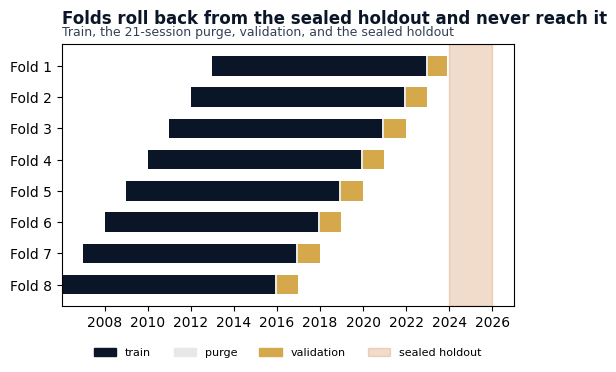

In [13]:
splits = generate_cv_splits(
    prices.select("timestamp"),
    case_study_id=CASE_STUDY_ID,
    label_buffer=LABEL_BUFFER,
    date_col="timestamp",
)
sessions = prices.select("timestamp").unique().sort("timestamp")["timestamp"].to_numpy()
purge_gaps = {
    int(
        (
            (sessions > np.datetime64(s["train_end"])) & (sessions < np.datetime64(s["val_start"]))
        ).sum()
    )
    for s in splits
}
last_val = max(s["val_end"] for s in splits)
assert len(splits) == SETUP["evaluation"]["n_splits"], "fold count differs from setup.yaml"
assert last_val < np.datetime64(HOLDOUT_START), "a fold reaches into the holdout"
assert purge_gaps == {PRIMARY_HORIZON}, "a purge gap is not the primary label horizon"

fig, ax = plt.subplots(figsize=FIGSIZE["single"])
fold_timeline(ax, splits, holdout=(HOLDOUT_START, HOLDOUT_END))
purge_note = f"Train, the {PRIMARY_HORIZON}-session purge, validation, and the sealed holdout"
add_message_title(ax, "Folds roll back from the sealed holdout and never reach it", purge_note)
plt.show()

## E. Derived artifacts

The eligibility table is the one thing this notebook hands downstream: `02_labels` and
`03_financial_features` semi-join on it, so a fund contributes rows only in years it cleared, and
it covers the sealed years too, since prior-year volume is all the rule ever reads.

In [14]:
eligibility.write_csv(CASE_DIR / "eligibility.csv")
print(f"Written: eligibility.csv, {len(eligibility):,} fund-year pairs")

Written: eligibility.csv, 1,670 fund-year pairs


## F. Findings vs `setup.yaml`

One row per knob: the evidence that motivates it, and what would change it.

| Knob | Evidence | Revise it when |
|---|---|---|
| `universe.eligibility_rule` | B.2 breadth at each decision date | breadth falls under the position count the sweep asks for |
| `decision.cadence` | B.3 exceedance | moves stop clearing the round trip, or the label horizon no longer fits inside one rebalancing interval |
| `costs.asset_spreads` | B.3 cost per fund from the declared commission and half-spread | quoted spreads become available and disagree with the assigned tier |
| `evaluation.n_splits` | D.2 fold boundaries | the folds no longer fit the development window |

In [15]:
print(
    f"universe.n_assets {SETUP['universe']['n_assets']}, eligible per decision date "
    f"{breadth['n_eligible'].min()} to {breadth['n_eligible'].max()}, under the floor on "
    f"{breadth.filter(pl.col('n_eligible') < BREADTH_FLOOR).height} of {len(breadth)} dates\n"
    f"decision.cadence {SETUP['decision']['cadence']} | labels.primary {PRIMARY_LABEL}\n"
    f"evaluation.n_splits {SETUP['evaluation']['n_splits']}, generated {len(splits)}, "
    f"last validation ends {last_val.date()}, holdout untouched"
)

universe.n_assets 100, eligible per decision date 0 to 96, under the floor on 12 of 216 dates
decision.cadence monthly_month_end | labels.primary fwd_ret_21d
evaluation.n_splits 8, generated 8, last validation ends 2023-11-29, holdout untouched


Eligible breadth runs from 0 in the first year, before any fund has a prior year to be admitted on,
to 96 of the declared 100, and sits under the position floor on 12 of 216 decision dates, every one
of them in that first year. Eight folds are generated, the last validation ending 2023-11-29.

## Key takeaways

1. **Decide membership on prior-year information, and count it on the decision date.** A liquidity
   filter fitted to the whole sample keeps the funds that stayed liquid.
2. **Convert a per-share cost into bps before comparing it to a return**, and scale each move by
   its own fund's round trip: a cent of spread is a different cost on a low-priced fund.
3. **Compute a panel autocorrelation inside each entity**, never across the stacked panel.

### Known limitations

- The funds in `universe.assets` were chosen knowing which of them still trade, so the
  point-in-time filter removes a bias inside the list and not the bias in the list itself.
- `close` is adjusted for splits and distributions, so early prices sit below what a fund traded
  at: dollar volume is understated there, and the round trip, being dollars per share over a
  price, is overstated. The half-spread is by tier, and the floor is not inflation-adjusted.
- Eligibility is annual while decisions are monthly, so a fund turning illiquid in March keeps its
  place until January.

**Next**: labels at the declared horizons, built on this development window.